In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
files = {
    "df_inj1": "../data/PNR/raw/PNR-1z_injection_rates.txt",
    "df_inj2": "../data/PNR/raw/PNR-2_injection_rates.txt",
    "df_cat1": "../data/PNR/raw/PNR-1z_microseismicity_catalogue.txt",
    "df_cat2": "../data/PNR/raw/PNR-2_microseismicity_catalogue.txt",
}

_read = lambda p: pd.read_csv(p, sep=r"\s+", skiprows=[0, 2], header=0)
for name, path in files.items():
    globals()[name] = _read(path)

In [ ]:
def add_datetime_column(df, out_col='ts', set_index=False,delete_original=False):
    candidates = {
        'year': ('year', 'Year', 'YEAR'),
        'month': ('month', 'Month', 'MONTH'),
        'day': ('day', 'Day', 'DAY', 'Day '),
        'hour': ('hr', 'hour', 'Hour', 'HR'),
        'minute': ('min', 'minute', 'Minute', 'MIN'),
        'second': ('sec', 'second', 'Second', 'SEC')
    }

    def _pick(col_names):
        for c in col_names:
            if c in df.columns:
                return c
        raise KeyError(f"None of {col_names} found in dataframe columns")

    picked = {k: _pick(v) for k, v in candidates.items()}

    # prepare subset and rename to pandas-expected names
    subset = df[[picked['year'], picked['month'], picked['day'],
                 picked['hour'], picked['minute'], picked['second']]].rename(
        columns={
            picked['year']: 'year',
            picked['month']: 'month',
            picked['day']: 'day',
            picked['hour']: 'hour',
            picked['minute']: 'minute',
            picked['second']: 'second'
        }
    )
    df[out_col] = pd.to_datetime(subset)
    if set_index:
        df.set_index(out_col, inplace=True)
    if delete_original:
        df.drop(columns=list(picked.values()), inplace=True)
    return df

In [3]:
for name in ("df_inj1", "df_inj2", "df_cat1", "df_cat2"):
    globals()[name] = add_datetime_column(globals()[name], out_col="ts", set_index=True, delete_original=True)

In [4]:
def normalize_catalog(df, index_name='ts', lon='Lon', lat='Lat', mag='Mag', depth='Z(km)'):
    rename_map = {}
    if lon in df.columns:
        rename_map[lon] = 'Longitude'
    if lat in df.columns:
        rename_map[lat] = 'Latitude'
    if mag in df.columns:
        rename_map[mag] = 'Magnitude'
    if depth in df.columns:
        rename_map[depth] = 'Depth'

    if rename_map:
        df = df.rename(columns=rename_map)

    desired = [index_name, 'Latitude', 'Longitude', 'Magnitude', 'Depth']
    existing = [c for c in desired if c in df.columns]
    return df[existing]

df_cat1 = normalize_catalog(df_cat1)
df_cat2 = normalize_catalog(df_cat2)
df_cat1

,Latitude,Longitude,Magnitude,Depth
ts,,,,
2018-10-15 13:24:02,53.7858,-2.97509,-1.828,-2.28428
2018-10-15 16:32:00,53.7860,-2.97186,-2.169,-2.27763
2018-10-15 18:49:04,53.7876,-2.96736,-2.290,-2.16380
2018-10-16 01:06:52,53.7879,-2.97051,-1.864,-2.28625
2018-10-16 10:54:18,53.7859,-2.97539,-1.563,-2.30682
...,...,...,...,...
2018-12-18 12:22:40,53.7866,-2.96574,-2.223,-2.40834
2018-12-18 12:22:42,53.7876,-2.96454,-1.895,-2.21559
2018-12-18 12:25:00,53.7879,-2.96438,-2.572,-2.23871


In [5]:
import pandas as pd
df_inj1.index = pd.to_datetime(df_inj1.index)
diff = df_inj1.index.to_series().diff()
gaps_greater_than_1min = diff[diff > pd.Timedelta(minutes=1)]
print(gaps_greater_than_1min.head())
print("总共大于1分钟的间隔：", len(gaps_greater_than_1min))

ts
2018-10-16 11:23:49   0 days 03:00:54
2018-10-17 08:49:27   0 days 00:42:28
2018-10-18 10:47:35   0 days 02:31:06
2018-10-19 08:58:25   0 days 00:12:00
2018-10-20 08:32:22   0 days 00:22:56
Name: ts, dtype: timedelta64[ns]
总共大于1分钟的间隔： 23


In [6]:
gaps_greater_than_1min

ts
2018-10-16 11:23:49    0 days 03:00:54
2018-10-17 08:49:27    0 days 00:42:28
2018-10-18 10:47:35    0 days 02:31:06
2018-10-19 08:58:25    0 days 00:12:00
2018-10-20 08:32:22    0 days 00:22:56
2018-10-22 08:24:55    0 days 00:13:27
2018-10-23 08:59:56    0 days 00:12:43
2018-10-24 08:56:09    0 days 00:41:08
2018-10-25 08:39:28    0 days 00:27:15
2018-10-26 08:52:19    0 days 00:23:27
2018-10-27 08:26:19    0 days 00:15:26
2018-10-29 08:49:15    1 days 08:49:31
2018-10-30 08:17:42    0 days 00:37:45
2018-10-31 08:48:59    0 days 01:11:26
2018-11-02 07:59:53    1 days 00:22:27
2018-12-08 07:35:21   35 days 07:35:53
2018-12-10 07:37:16    1 days 07:37:17
2018-12-11 07:34:45    0 days 00:04:40
2018-12-13 07:31:31    1 days 00:06:36
2018-12-14 07:30:09    0 days 00:05:38
2018-12-15 07:27:29    0 days 00:03:53
2018-12-15 12:45:34    0 days 00:14:32
2018-12-17 07:33:57    0 days 00:08:44
Name: ts, dtype: timedelta64[ns]

In [7]:
df_inj1_m = df_inj1.resample('min').mean()
df_inj1_m.rename(columns={'injection_rate(m^3/min)': 'IR_h'}, inplace=True)
df_inj2_m = df_inj2.resample('min').sum()
df_inj2_m.rename(columns={'injection_rate(m^3/s)': 'IR_h'}, inplace=True)

In [ ]:
import pandas as pd
df_inj1_m.index = pd.to_datetime(df_inj1_m.index)
new_index = pd.date_range(start=df_inj1_m.index.min(), end='2018-12-18 12:31:00', freq='min')
df_inj1_m = df_inj1_m.reindex(new_index, fill_value=0)
df_inj1_m['IR_h'] = df_inj1_m['IR_h'].fillna(0)
df_inj1_m.index.name = 'ts'
print(df_inj1_m.isna().sum())

IR_h    0
dtype: int64


In [10]:
df_cat1.to_csv("../data/PNR/raw/PNR_1z_catalog.csv")
df_cat2.to_csv("../data/PNR/raw/PNR_2z_catalog.csv")

In [11]:
df_inj1_m.to_csv("../data/PNR/raw/PNR_1z_injection_rate_per_min.csv")

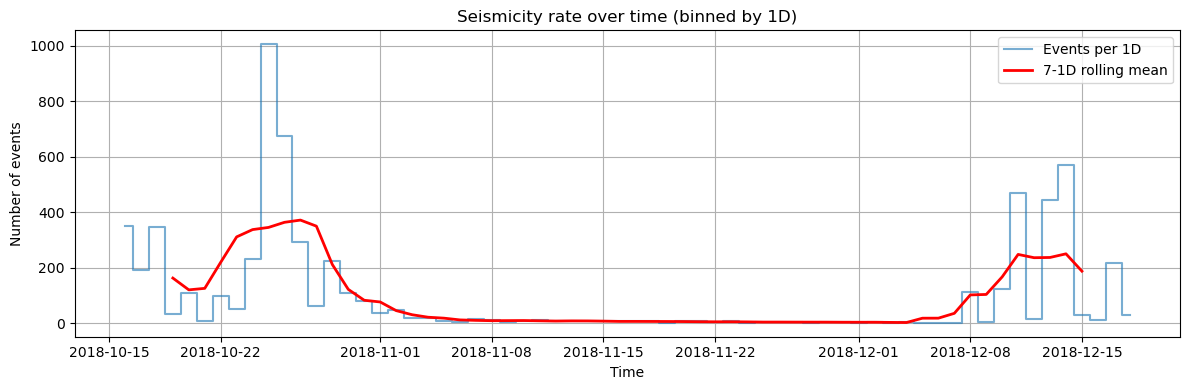

In [12]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
df_cat1_filtered = df_cat1[df_cat1['Magnitude'] >= -1.5]
event_counts = df_cat1_filtered.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()

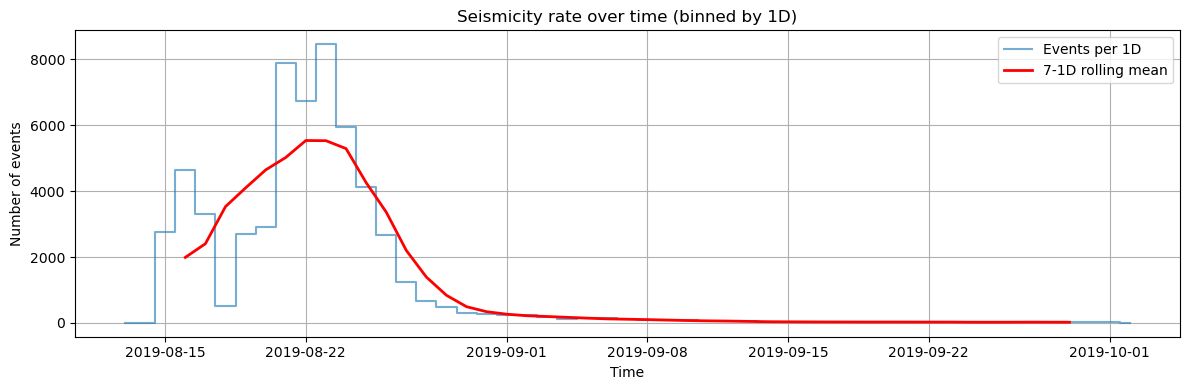

In [13]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
event_counts = df_cat2.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()


<Axes: >

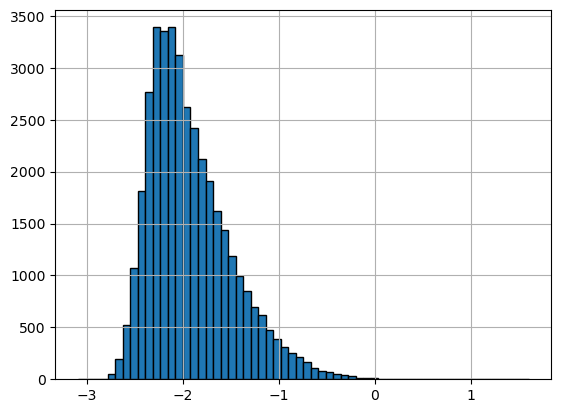

In [14]:
df_cat1['Magnitude'].hist(bins=60, edgecolor='black')

In [15]:
len(df_cat2[df_cat2['Magnitude']>-2])

54257

In [16]:
inj1_sch = pd.read_csv("../data/PNR/raw/pnr1z_inj_sch.csv")
inj2_sch = pd.read_csv("../data/PNR/raw/pnr2_inj_sch.csv")

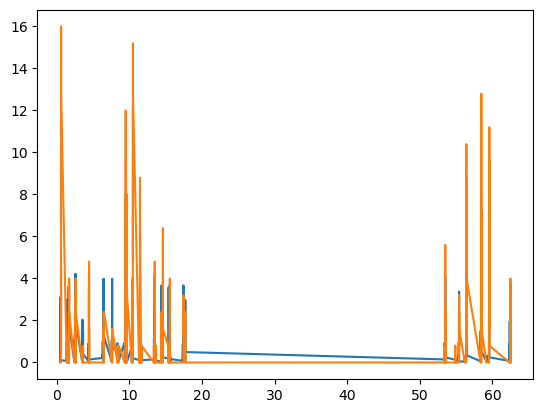

In [29]:
plt.plot(inj1_sch['T'], inj1_sch['IR'])
plt.plot(inj1_sch['T'], inj1_sch['SR']*0.8)

In [21]:
df_inj1_h= df_inj1.resample('h').mean()
df_inj2_h= df_inj2.resample('h').sum()/60
df_inj1_h.rename(columns={'injection_rate(m^3/min)':'IR_h'}, inplace=True)
df_inj2_h.rename(columns={'injection_rate(m^3/s)':'IR_h'}, inplace=True)


<Axes: xlabel='ts'>

/home/yzzhang/.local/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/yzzhang/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


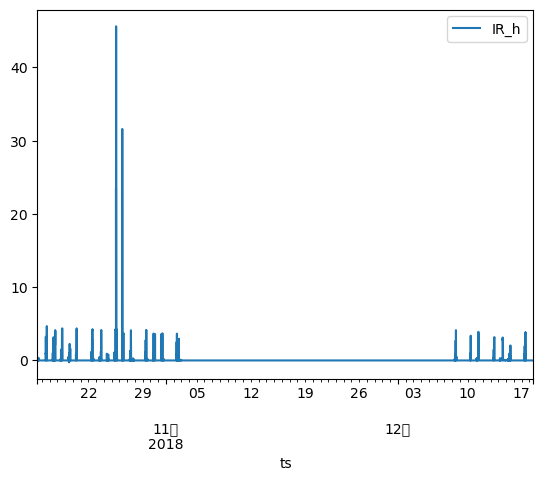

In [22]:
df_inj1_m.plot()

In [20]:
event_counts_min = df_cat1.resample('T').size()
event_counts_min.head()

/tmp/ipykernel_3906022/2704100517.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  event_counts_min = df_cat1.resample('T').size()


ts
2018-10-15 13:24:00    1
2018-10-15 13:25:00    0
2018-10-15 13:26:00    0
2018-10-15 13:27:00    0
2018-10-15 13:28:00    0
Freq: min, dtype: int64

<Axes: xlabel='ts'>

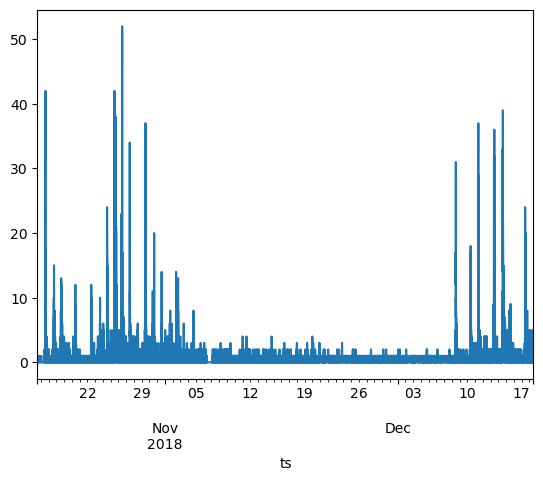

In [21]:
event_counts_min.plot()

In [22]:
# 找到最后一个注入量非0的时间（以 df_inj2_h 为例）
nonzero = df_inj2_h[df_inj2_h.iloc[:, 0] != 0]
if nonzero.empty:
    last_nonzero_date = None
    print("没有非0注入量的记录")
else:
    last_nonzero_date = nonzero.index.max()
    print(last_nonzero_date)

2019-08-23 15:00:00


In [23]:
df_inj2_h

,IR_h
ts,
2019-08-13 16:00:00,0.000000
2019-08-13 17:00:00,0.030531
2019-08-13 18:00:00,0.000000
2019-08-13 19:00:00,0.000000
2019-08-13 20:00:00,0.000000
...,...
2019-10-02 01:00:00,0.000000
2019-10-02 02:00:00,0.000000
2019-10-02 03:00:00,0.000000


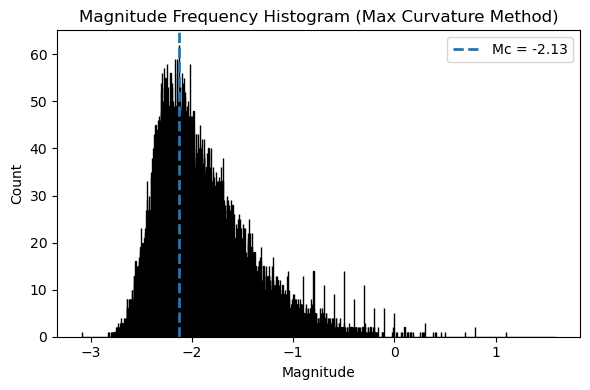

Estimated Mc = -2.13


In [24]:
from  src.data.preprocessing import estimate_mc_max_curvature
mags = df_cat1["Magnitude"].values
mc, bin_centers, counts = estimate_mc_max_curvature(mags, bin_width=0.001, plot=True)
print(f"Estimated Mc = {mc:.2f}")

In [25]:
df = pd.read_csv("../data/PNR/raw/PNR_1z_catalog.csv", parse_dates=['ts'])
start_ts = pd.Timestamp("2018-10-15 12:00:00")
arrival_times = ((df['ts'] - start_ts) / pd.Timedelta("1h")).values

In [26]:
df['ts']

0       2018-10-15 13:24:02
1       2018-10-15 16:32:00
2       2018-10-15 18:49:04
3       2018-10-16 01:06:52
4       2018-10-16 10:54:18
                ...        
38437   2018-12-18 12:22:40
38438   2018-12-18 12:22:42
38439   2018-12-18 12:25:00
38440   2018-12-18 12:30:13
38441   2018-12-18 12:30:56
Name: ts, Length: 38442, dtype: datetime64[ns]

In [27]:
arrival_times

array([1.40055556e+00, 4.53333333e+00, 6.81777778e+00, ...,
       1.53641667e+03, 1.53650361e+03, 1.53651556e+03])